# EDA - Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_dataset.csv')

In [3]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day,dayofweek,dayofyear
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024,5,16,3,137
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024,5,16,3,137
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024,5,16,3,137
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024,5,16,3,137
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,16,3,137


In [4]:
# Numeric columns
df.select_dtypes(include=np.number).columns

Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination', 'year', 'month',
       'day', 'dayofweek', 'dayofyear'],
      dtype='object')

In [5]:
# categorical columns
df.select_dtypes(include='object').columns

Index(['country', 'location_name', 'timezone', 'last_updated',
       'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase'],
      dtype='object')

## Temperature Distribution

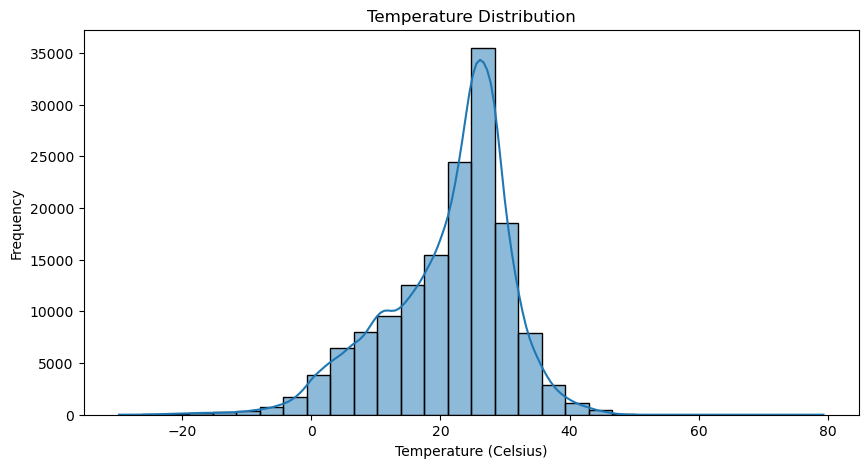

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(df['temperature_celsius'], bins=30, kde=True)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Frequency')
plt.show()

## Humidity Distribution

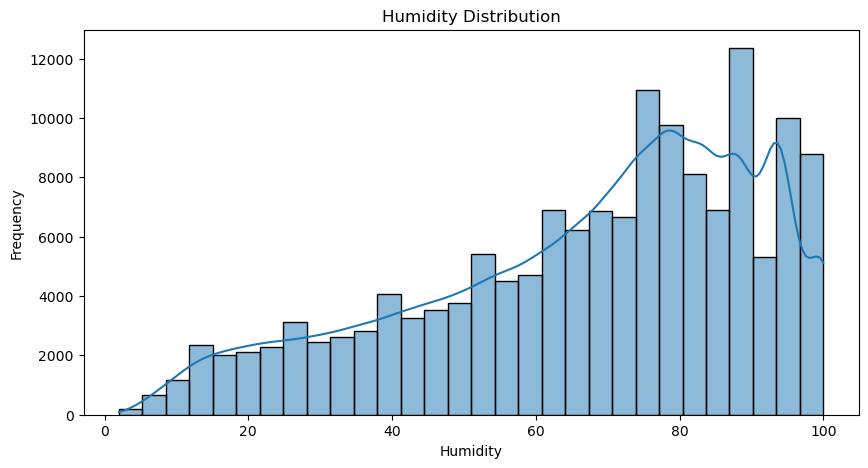

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df['humidity'], bins=30, kde=True)
plt.title('Humidity Distribution')
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.show()

## Precipitation Distribution

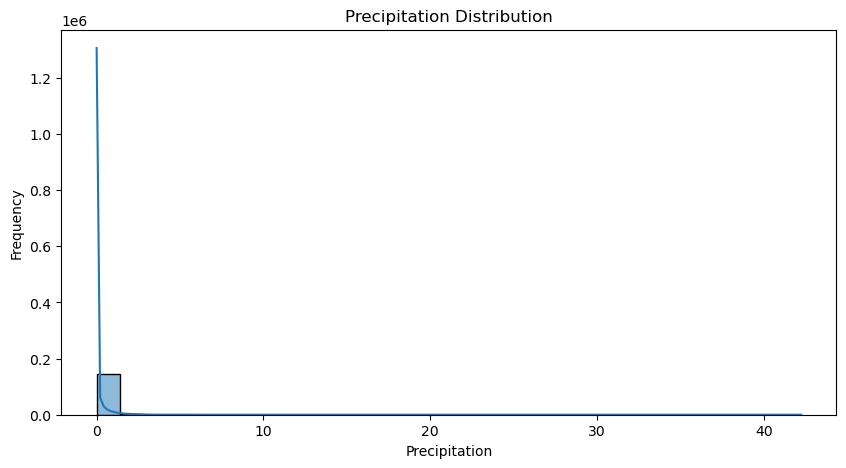

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(df['precip_mm'], bins=30, kde=True)
plt.title('Precipitation Distribution')
plt.xlabel('Precipitation')
plt.ylabel('Frequency')
plt.show()

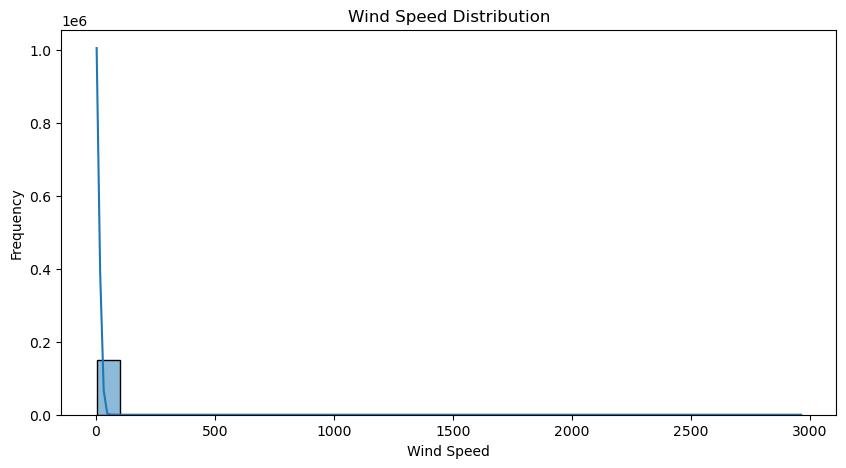

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df['wind_kph'], bins=30, kde=True)
plt.title('Wind Speed Distribution')
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.show()

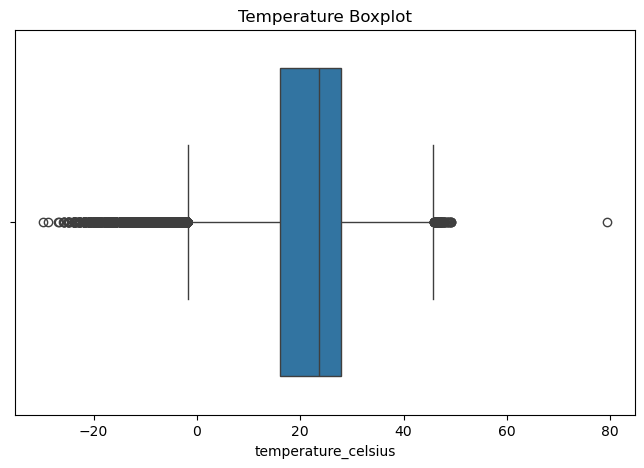

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["temperature_celsius"])

plt.title("Temperature Boxplot")
plt.show()

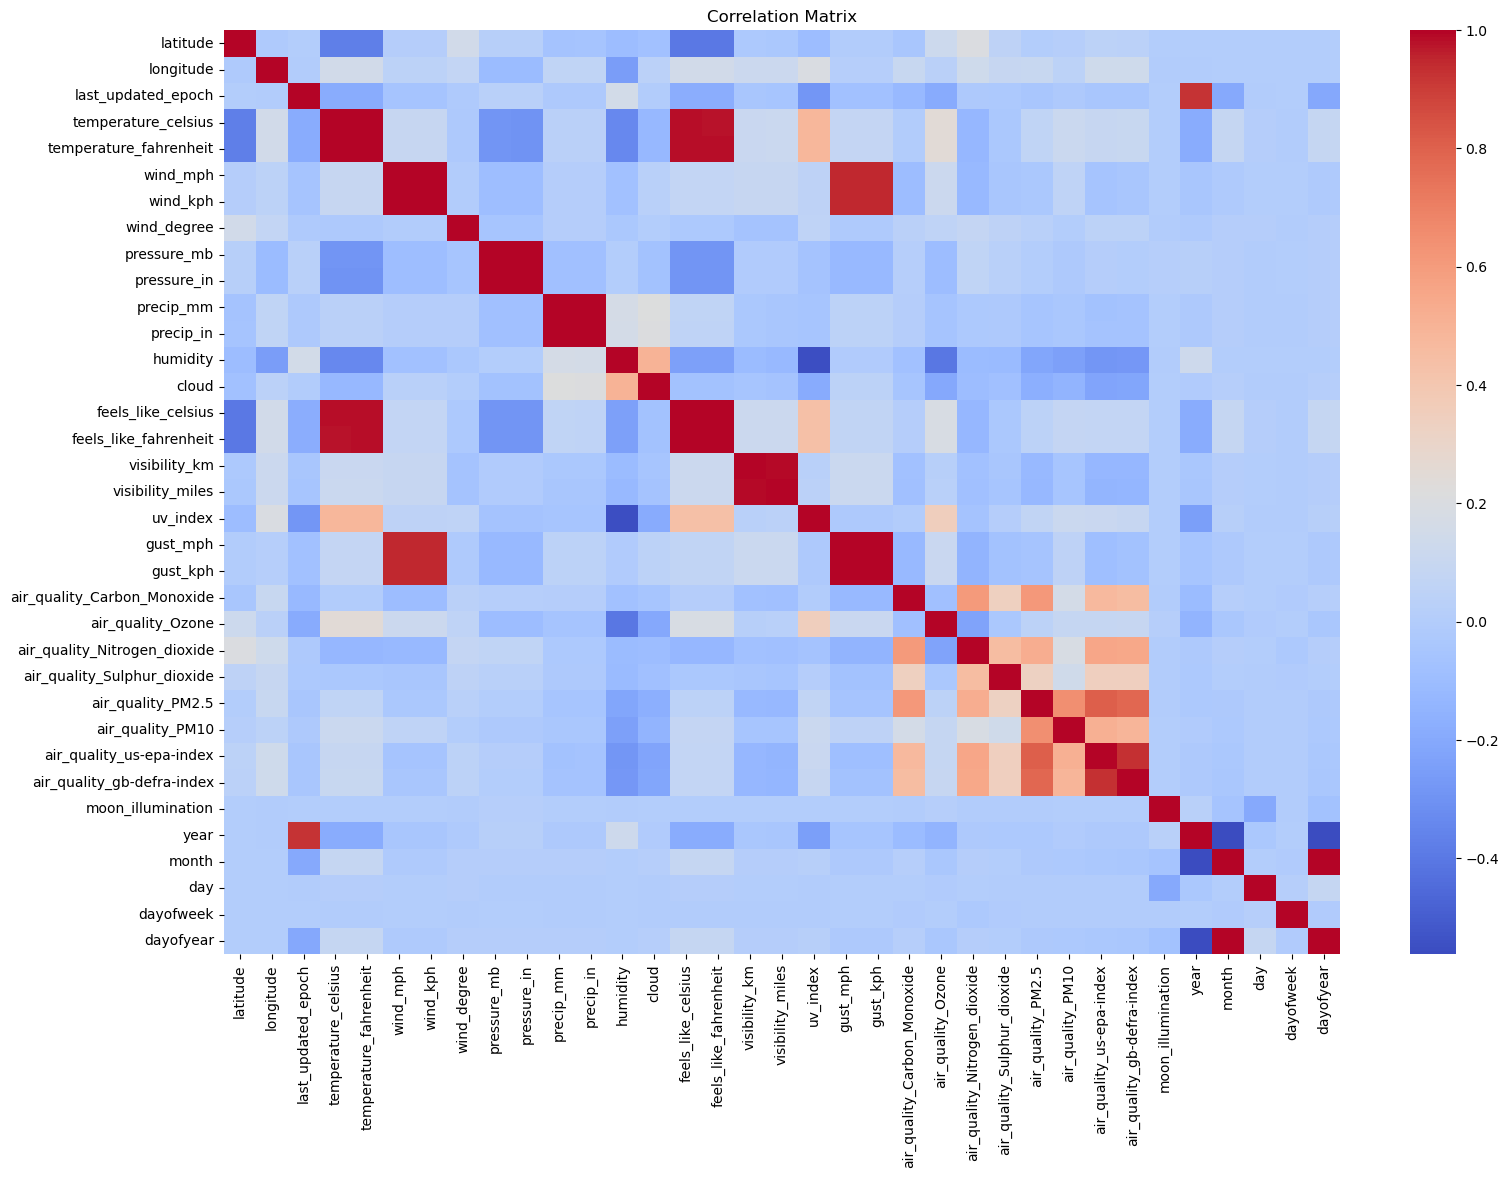

In [11]:
plt.figure(figsize=(18,12))

corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr,cmap="coolwarm",annot=False)

plt.title("Correlation Matrix")
plt.show()

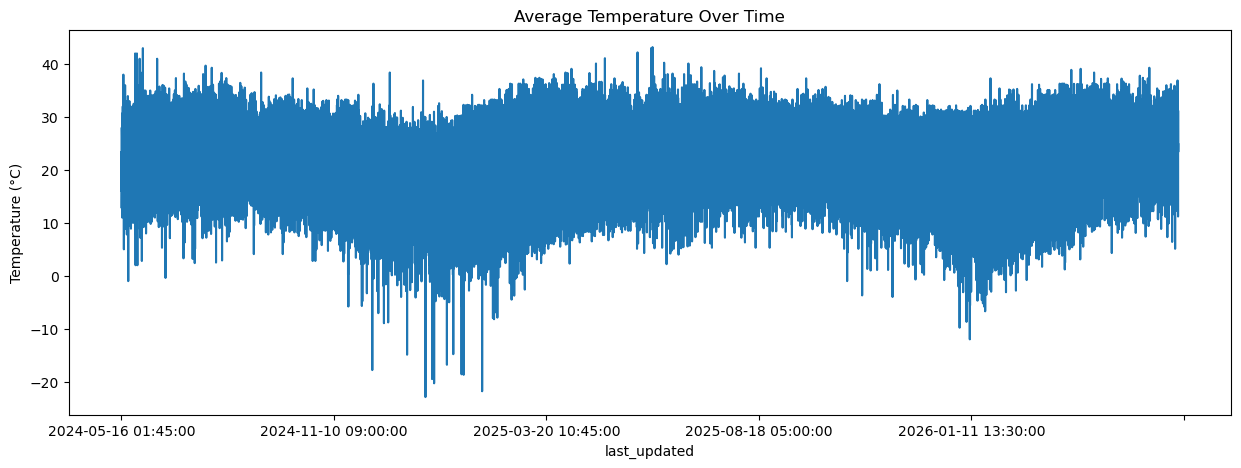

In [12]:
daily_temp = df.groupby("last_updated")["temperature_celsius"].mean()

plt.figure(figsize=(15,5))

daily_temp.plot()

plt.title("Average Temperature Over Time")
plt.ylabel("Temperature (°C)")

plt.show()

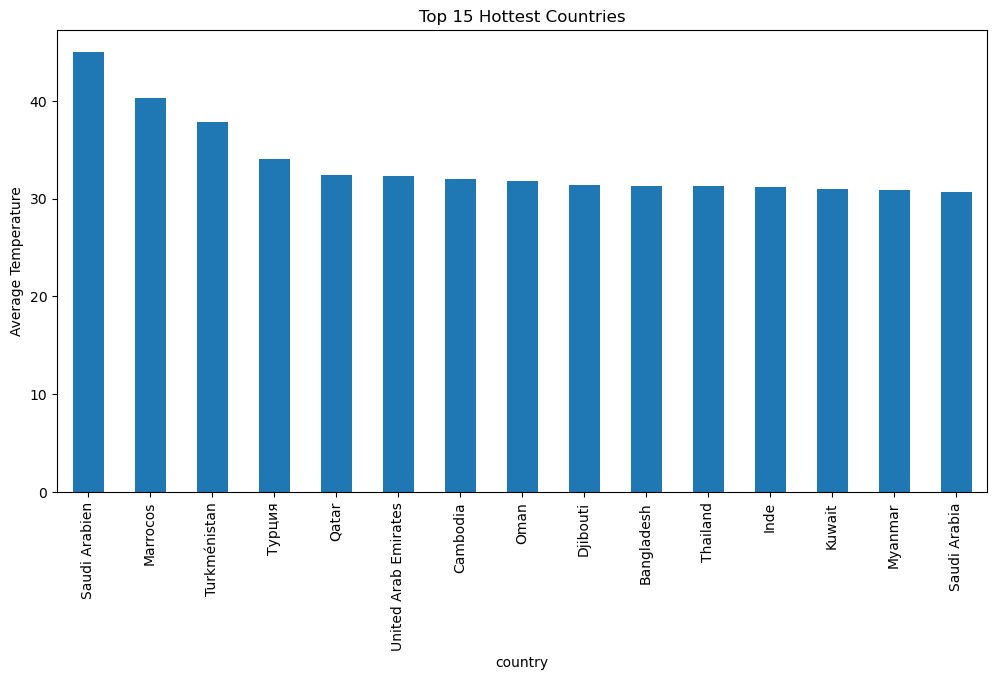

In [13]:
country_temp = (
    df.groupby("country")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

country_temp.plot(kind="bar")

plt.title("Top 15 Hottest Countries")

plt.ylabel("Average Temperature")

plt.show()

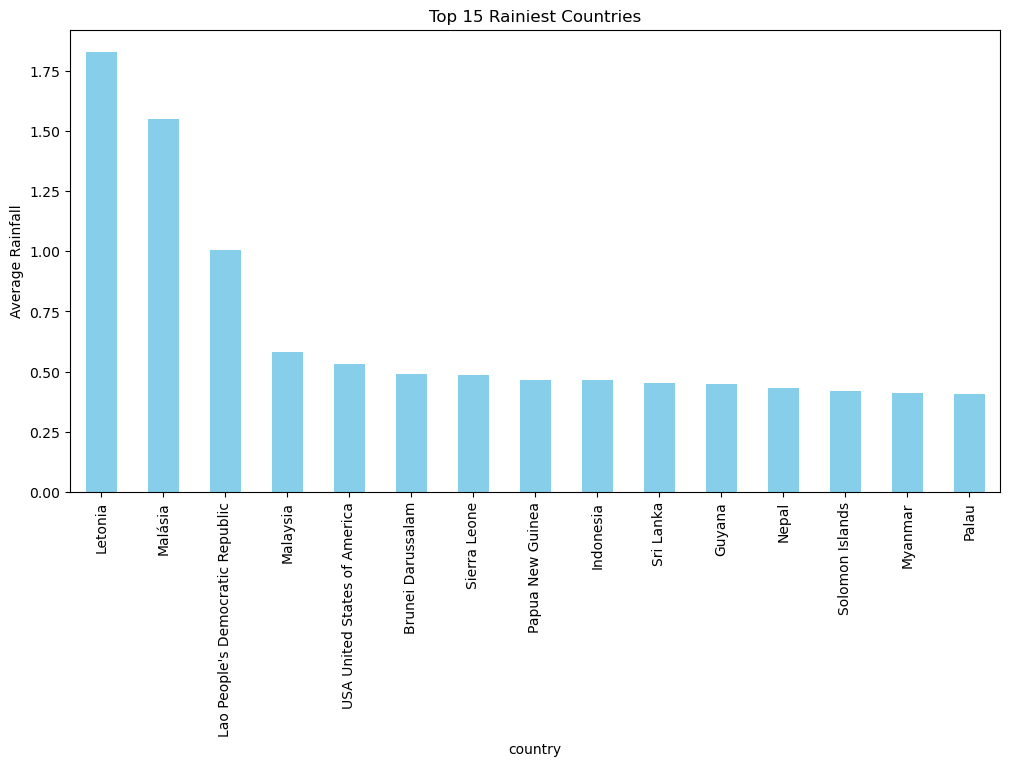

In [14]:
country_rain = (
    df.groupby("country")["precip_mm"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

country_rain.plot(kind="bar",
                  color="skyblue")

plt.title("Top 15 Rainiest Countries")

plt.ylabel("Average Rainfall")

plt.show()

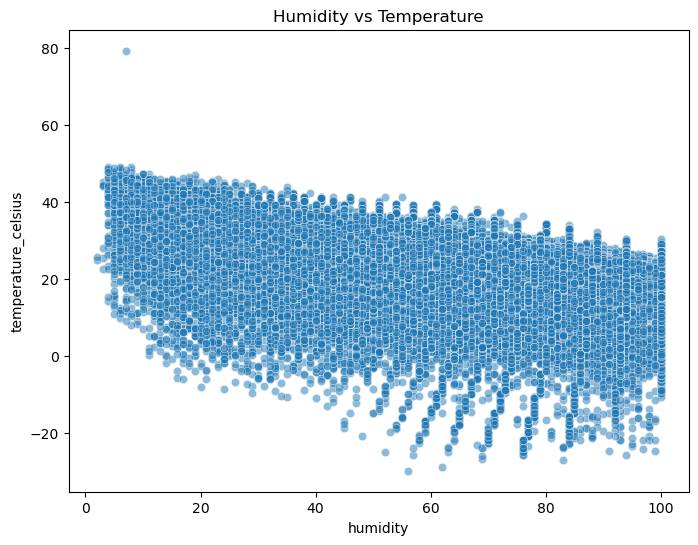

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="humidity",
    y="temperature_celsius",
    alpha=0.5
)

plt.title("Humidity vs Temperature")

plt.show()

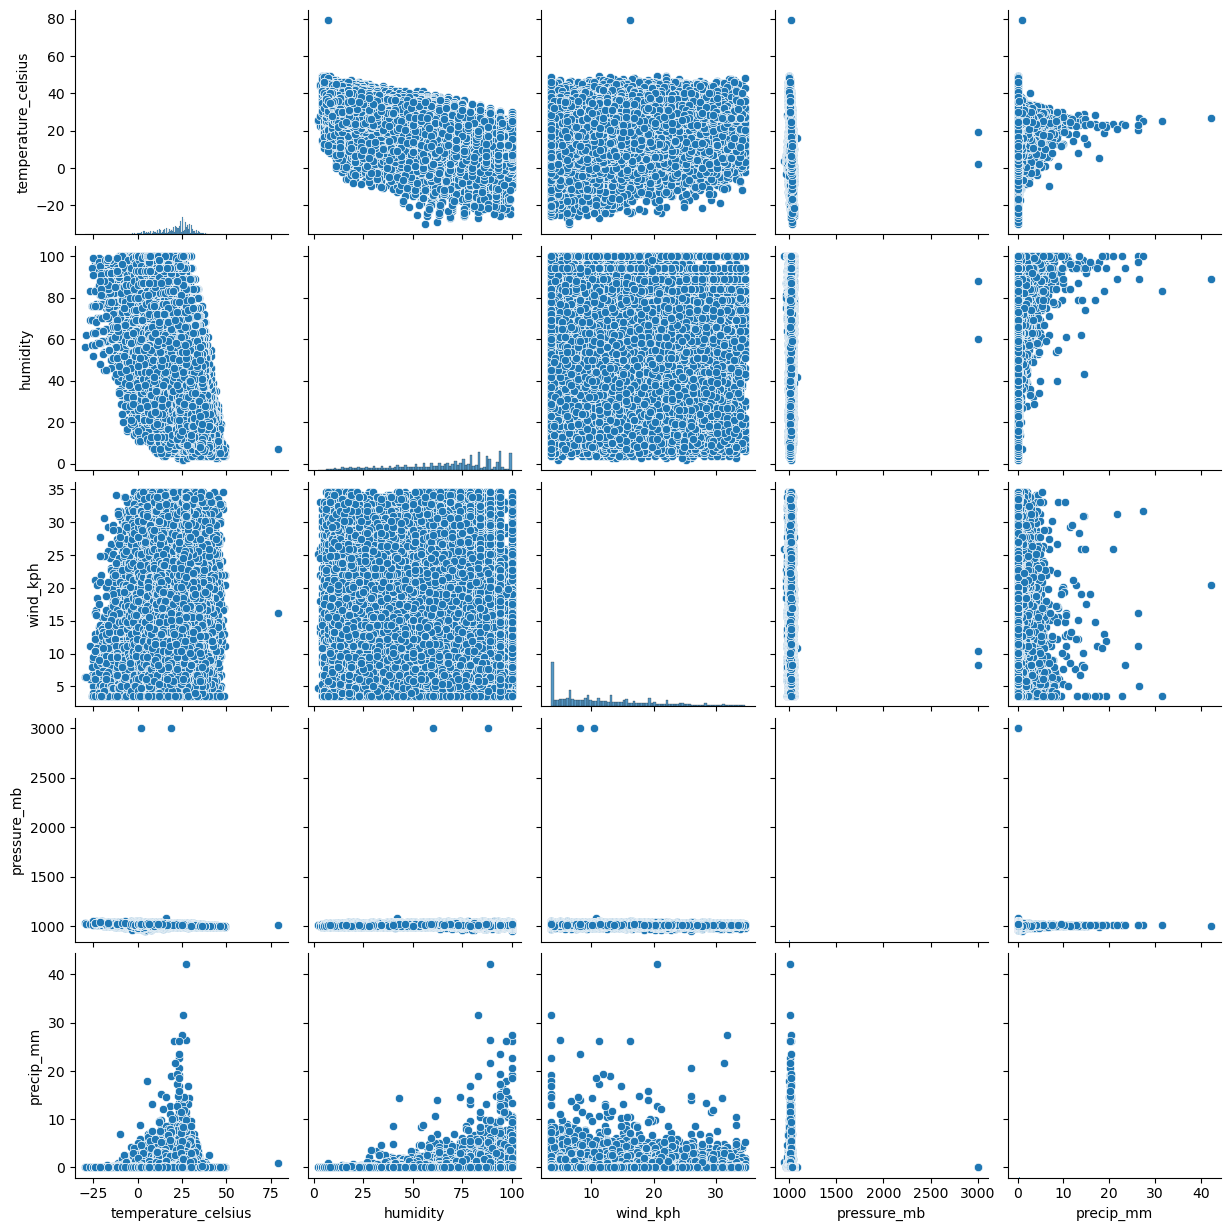

In [25]:
cols = [
    "temperature_celsius",
    "humidity",
    "wind_kph",
    "pressure_mb",
    "precip_mm"
]

sns.pairplot(df[cols])

plt.show()

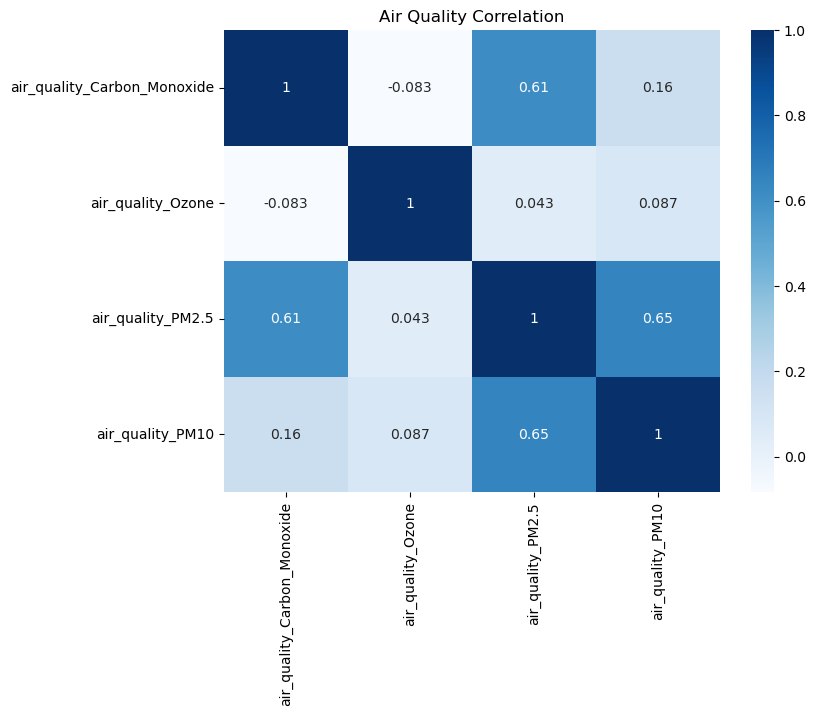

In [24]:
air_cols = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[air_cols].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Air Quality Correlation")

plt.show()

## Outlier Detection

In [16]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column}")
    print(f"Lower Limit : {lower:.2f}")
    print(f"Upper Limit : {upper:.2f}")
    print(f"Outliers : {len(outliers)}")
    print("-"*40)

In [17]:
detect_outliers(df, "temperature_celsius")
detect_outliers(df, "wind_kph")
detect_outliers(df, "precip_mm")

temperature_celsius
Lower Limit : -1.85
Upper Limit : 45.75
Outliers : 2646
----------------------------------------
wind_kph
Lower Limit : -11.15
Upper Limit : 34.85
Outliers : 2509
----------------------------------------
precip_mm
Lower Limit : -0.03
Upper Limit : 0.05
Outliers : 30181
----------------------------------------


In [18]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[column] >= lower) & (df[column] <= upper)]

    return df

In [19]:
df = remove_outliers(df, "wind_kph")

In [20]:
print(df[["temperature_celsius", "wind_kph", "precip_mm"]].describe())

       temperature_celsius       wind_kph      precip_mm
count        147371.000000  147371.000000  147371.000000
mean             21.327625      12.305205       0.129578
std               9.531445       7.515356       0.546048
min             -29.800000       3.600000       0.000000
25%              16.000000       6.100000       0.000000
50%              23.700000      10.400000       0.000000
75%              27.900000      16.900000       0.020000
max              79.300000      34.600000      42.240000


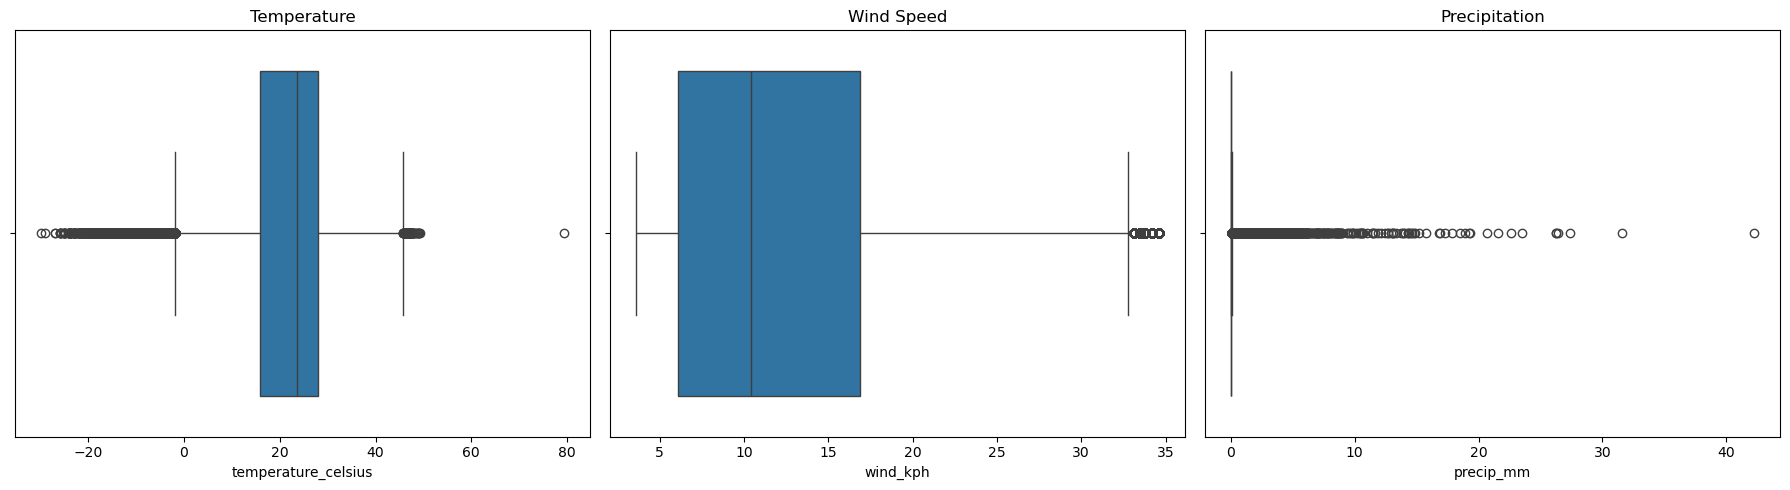

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df["temperature_celsius"], ax=axes[0])
axes[0].set_title("Temperature")

sns.boxplot(x=df["wind_kph"], ax=axes[1])
axes[1].set_title("Wind Speed")

sns.boxplot(x=df["precip_mm"], ax=axes[2])
axes[2].set_title("Precipitation")

plt.tight_layout()
plt.show()

### Outlier Analysis

The IQR method was used to identify potential outliers in numerical features.

However, weather data naturally contains extreme values due to varying climatic conditions across different regions. For example:

- Temperature ranged from **-24.9°C to 49.2°C**, which is realistic for global weather data.
- Wind speed ranged from **3.6 to 34.9 km/h**, which falls within a normal range.
- Precipitation reached **42.24 mm**, representing heavy rainfall events rather than erroneous values.

Therefore, only wind outliers were removed, as they represent genuine weather phenomena and are important for accurate forecasting.

## Advanced EDA

In [22]:
from sklearn.ensemble import IsolationForest

features = df[["temperature_celsius","humidity","wind_kph","pressure_mb"]]

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

df["Anomaly"] = iso.fit_predict(features)

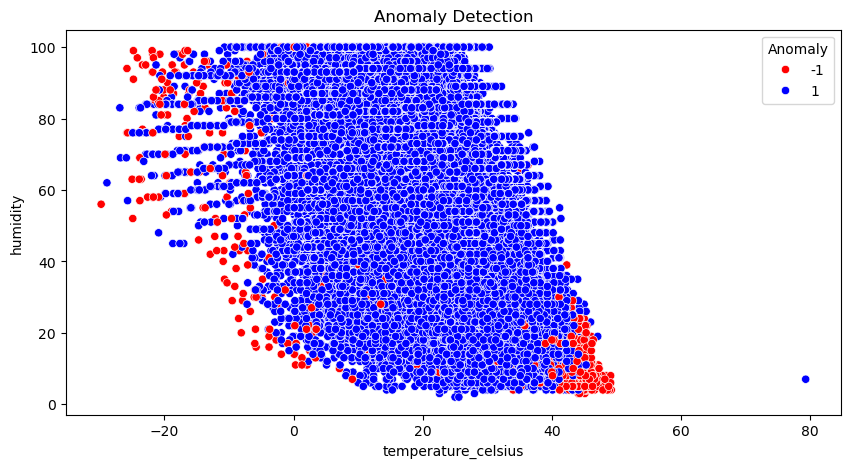

In [23]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="temperature_celsius",
    y="humidity",
    hue="Anomaly",
    palette=["red","blue"]
)

plt.title("Anomaly Detection")
plt.show()